## **SEEDS DATASET**

### **1. Data Loading and Initial Inspection**

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
import numpy as np
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
cols = [
    "area",
    "perimeter",
    "compactness",
    "kernel_length",
    "kernel_width",
    "asymmetry_coefficient",
    "kernel_groove_length",
    "label"
]

df = pd.read_csv(
    "seeds_dataset.tsv",
    sep=r"\s+",
    header=None,
    names=cols
)

df.head(10)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,label
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1


In [3]:
# Basic information about the dataset
print("\nDataset Shape:", df.shape)
print("Column Names:", df.columns.tolist())
print("Data Types:\n", df.dtypes)



Dataset Shape: (210, 8)
Column Names: ['area', 'perimeter', 'compactness', 'kernel_length', 'kernel_width', 'asymmetry_coefficient', 'kernel_groove_length', 'label']
Data Types:
 area                     float64
perimeter                float64
compactness              float64
kernel_length            float64
kernel_width             float64
asymmetry_coefficient    float64
kernel_groove_length     float64
label                      int64
dtype: object


The dataset was loaded into a structured format with the following seven geometric features and one target label:

- **Area ($A$):** The total surface area of the seed.
- **Perimeter ($P$):** The length of the outer boundary.
- **Compactness ($C$):** Calculated as:

  $$
  C = \frac{4\pi A}{P^2}
  $$

  It measures how close the seed shape is to a perfect circle.

- **Kernel Length:** The longest dimension of the seed.
- **Kernel Width:** The dimension perpendicular to the length.
- **Asymmetry Coefficient:** A measure of the irregularity of the seed's shape.
- **Kernel Groove Length:** The length of the natural indentation (groove) on the seed.
- **Label:** The wheat category:
  - `1`: Kama
  - `2`: Rosa
  - `3`: Canadian

#### Results

- **Dataset Shape:** 210 rows and 8 columns.
- **Data Types:** All features are floating-point numbers, and the label is an integer.

### **2. Descriptive Statistics & Class Distribution**

In [9]:
#summary statistics
print("\nSummary Statistics:\n" )
desc_overall = df.describe()
desc_overall


Summary Statistics:



,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient,kernel_groove_length,label
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [8]:
# ⁠Generate descriptive statistics table (mean, std, min, max, quartiles) — per feature and per class
desc_per_class = df.groupby('label').describe()
desc_per_class

area                                                               \
      count       mean       std    min      25%     50%      75%    max   
label                                                                      
1      70.0  14.334429  1.215704  11.23  13.7500  14.355  15.0450  17.08   
2      70.0  18.334286  1.439496  15.38  17.3300  18.720  19.1375  21.18   
3      70.0  11.873857  0.723004  10.59  11.2625  11.835  12.4250  13.37   

      perimeter             ... asymmetry_coefficient         \
          count       mean  ...                   75%    max   
label                       ...                                
1          70.0  14.294286  ...               3.30100  6.685   
2          70.0  16.135714  ...               4.43600  6.682   
3          70.0  13.247857  ...               5.46725  8.456   

      kernel_groove_length                                             \
                     count      mean       std    min     25%     50%   
label                                                                   
1                     70.0  5.087214  0.263699  4.519  4.9245  5.0940   
2                     70.0  6.020600  0.253934  5.144  5.8775  5.9815   
3                     70.0  5.116400  0.162068  4.745  5.0020  5.0915   

                       
           75%    max  
label                  
1      5.22350  5.877  
2      6.18775  6.550  
3      5.22850  5.491  

[3 rows x 56 columns]

The statistical summary reveals significant differences in the physical dimensions of the three wheat varieties.

- **Label 2 (Rosa) :** Exhibits the largest physical dimensions, with an average Area of approximately $18.33$ units.
- **Label 3 (Canadian):** Features the smallest physical dimensions, with an average Area of approximately $11.87$ units.
- **Label 1 (Kama):** Sits in the middle with an average Area of approximately $14.85$ units.

#### Class Distribution

The dataset is perfectly balanced with exactly **70 samples** for each variety, ensuring that any classification model trained on this data will not have a frequency-based bias.

### **3. Data Quality**

In [6]:

# Checking for missing values and duplicates
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()
print("\nMissing values per column:\n", missing_values)
print("Number of duplicate rows:", duplicates)


Missing values per column:
 area                     0
perimeter                0
compactness              0
kernel_length            0
kernel_width             0
asymmetry_coefficient    0
kernel_groove_length     0
label                    0
dtype: int64
Number of duplicate rows: 0


- **Missing Values:** The dataset is complete. No null or missing entries were detected in any of the 210 records.  

- **Duplicates:** No identical rows were found, indicating that every observation provides unique data.

### **4. Class Distribution Visualization (countplot)**


Samples per wheat variety:
 label
1    70
2    70
3    70
Name: count, dtype: int64


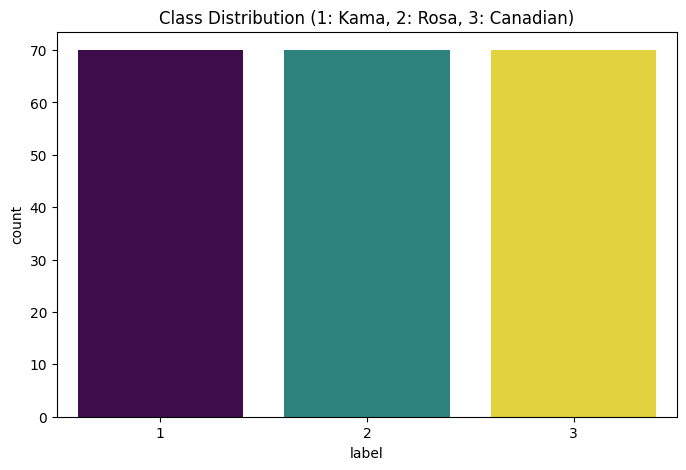

In [10]:
#  Class distribution
class_counts = df['label'].value_counts()
print("\nSamples per wheat variety:\n", class_counts)

plt.figure(figsize=(8, 5))
# Fixing the deprecation: assign x to hue and set legend=False
sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution (1: Kama, 2: Rosa, 3: Canadian)')
plt.savefig('task5_countplot.png')

##### There are exactly **70 samples** for each label. This balance is ideal for training classification models as it prevents the model from developing a bias toward a majority class.

### **5. Univariate Analysis (Histograms)**

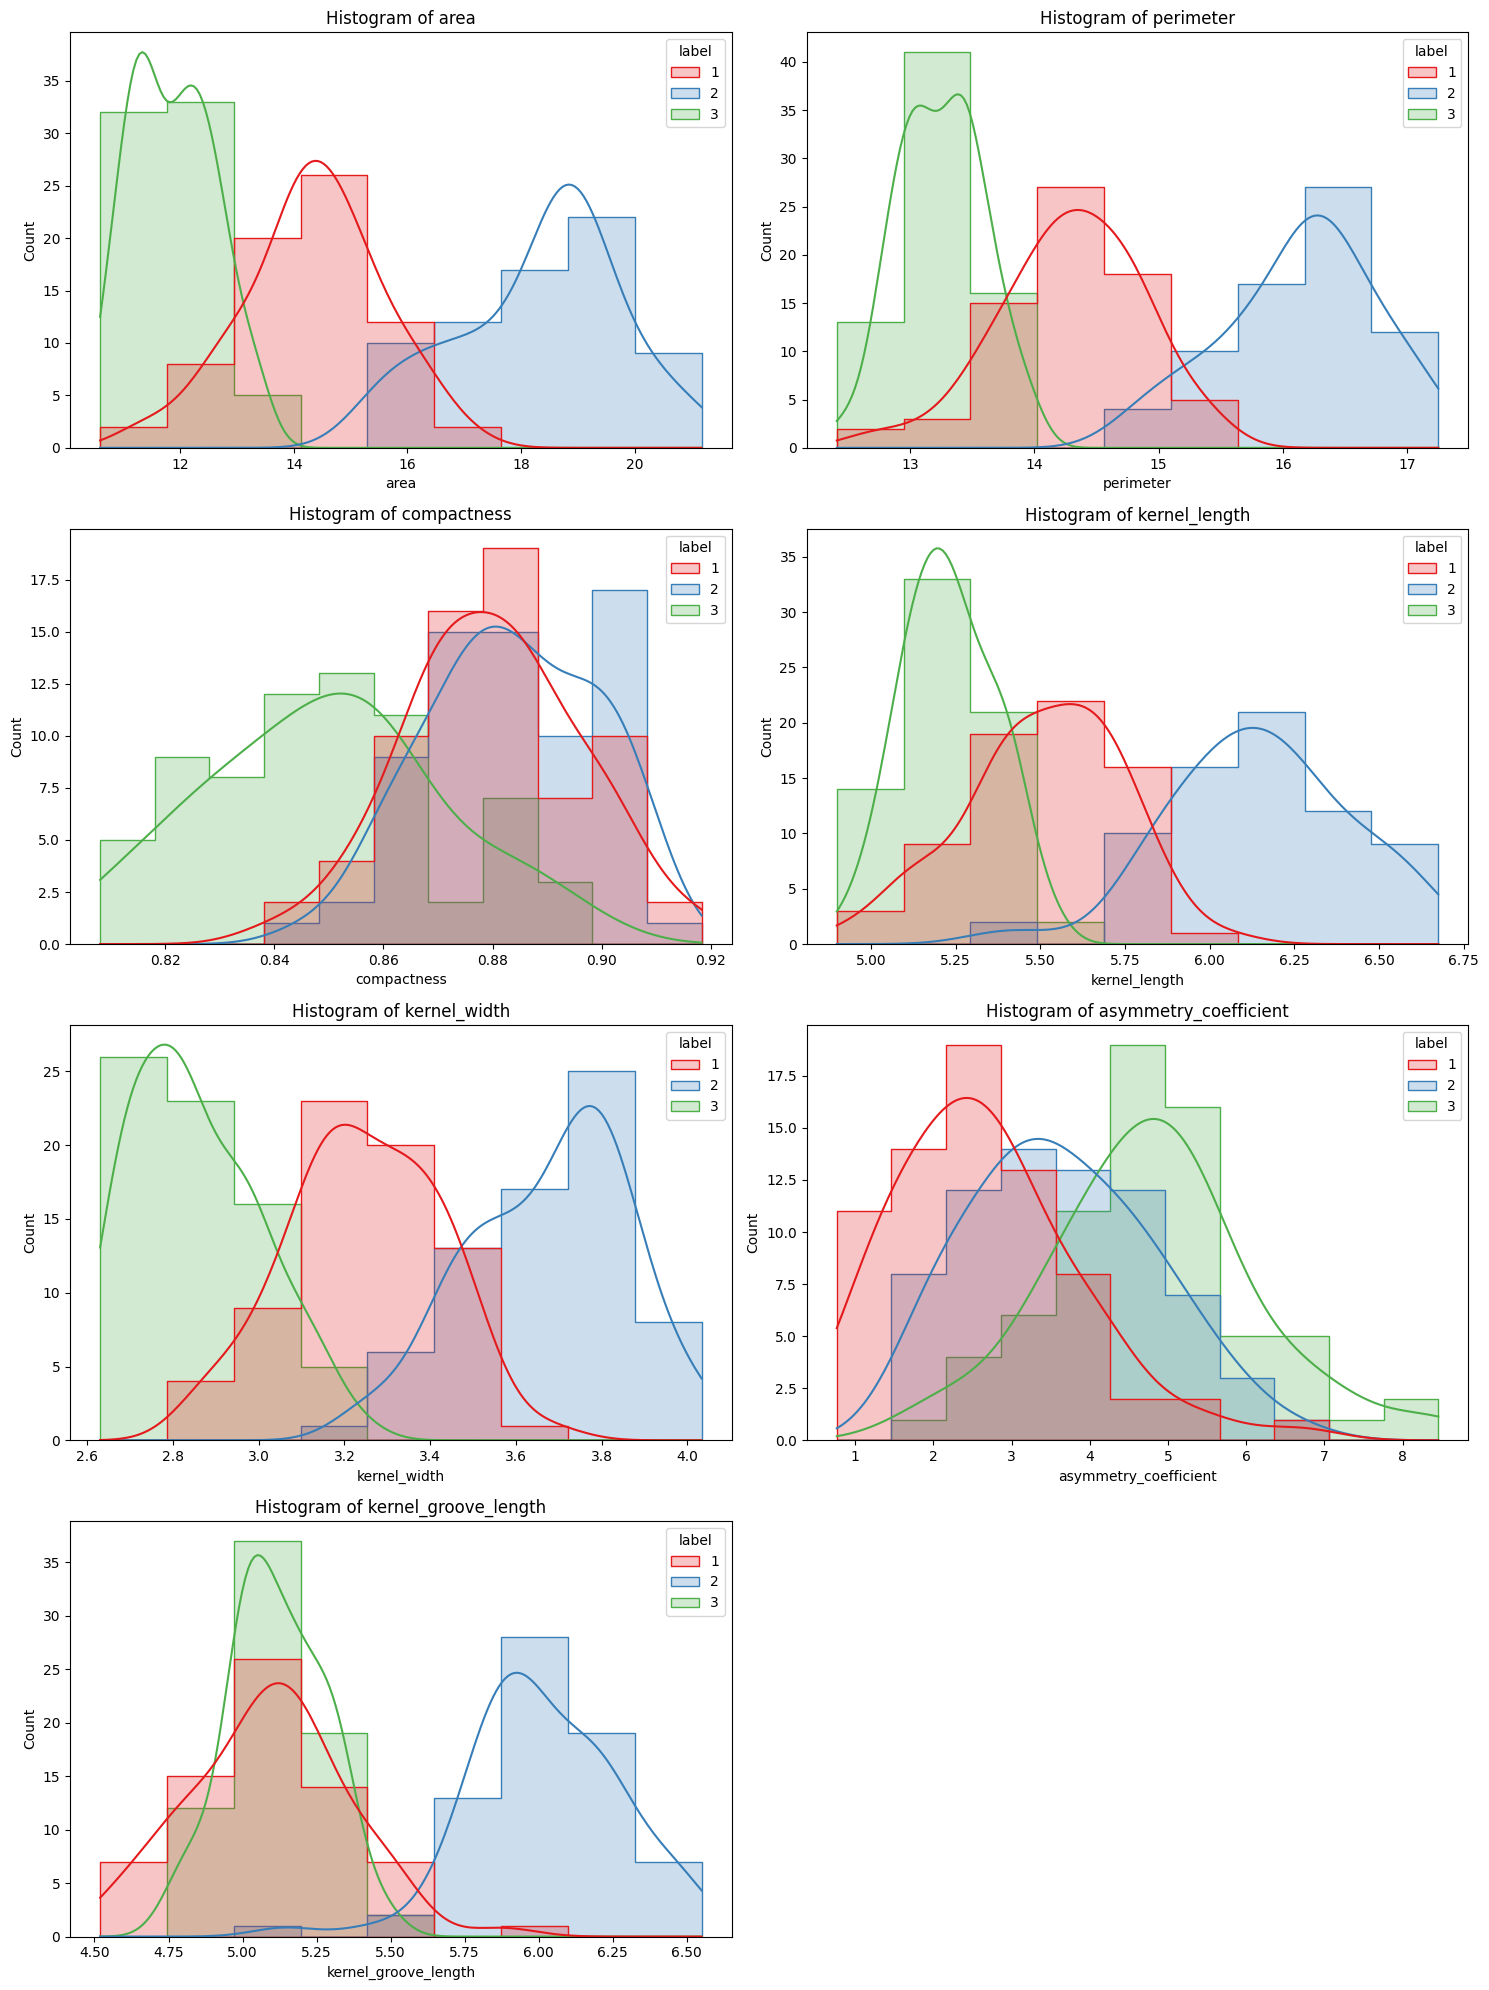

In [11]:
#  Histograms for  7 features
features = cols[:-1]
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='label', kde=True, ax=axes[i], palette='Set1', element='step')
    axes[i].set_title(f'Histogram of {col}')

# Remove the empty 8th subplot
fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig('feature_histograms.png')

 - **Separability:** Features like **Area** and **Perimeter** show distinct "peaks" for each variety, particularly for label 2 (Rosa), which is shifted far to the right.  

 - **Overlap:** The **Asymmetry Coefficient** shows the highest degree of overlap between all three classes, indicating that it is a poor predictor when used in isolation.

### **6. Outlier Detection (Boxplots & IQR)**

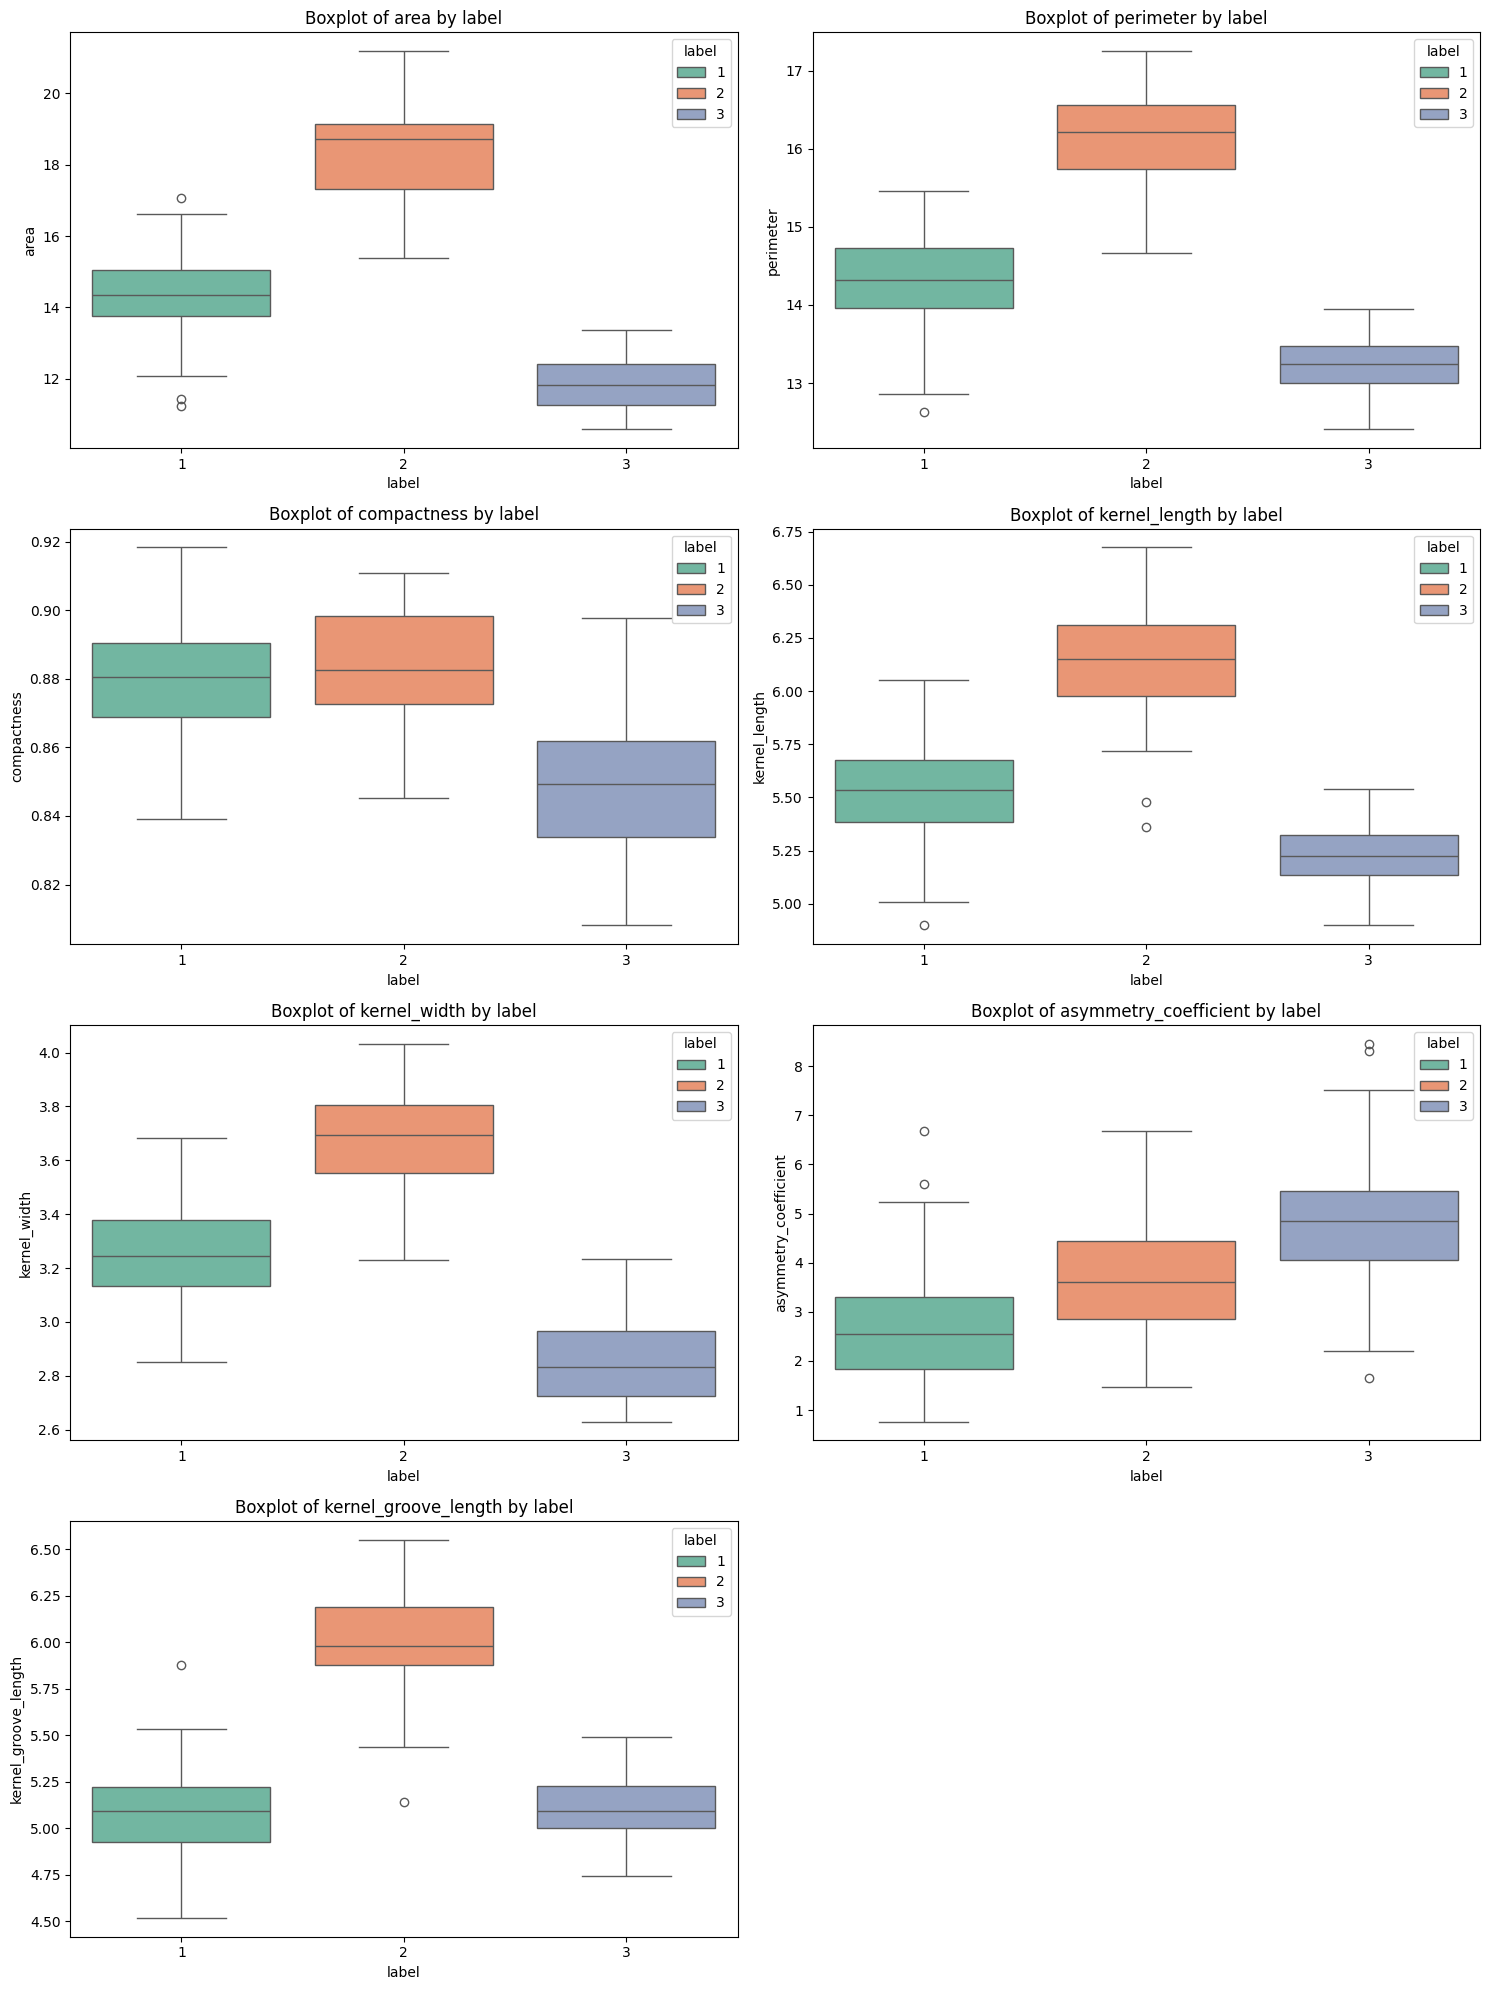

In [12]:
# Boxplots for features grouped by class

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='label', y=col, hue='label', palette='Set2', ax=axes[i])
    axes[i].set_title(f'Boxplot of {col} by label')

fig.delaxes(axes[7])
plt.tight_layout()
plt.savefig('feature_boxplots.png')

##### The boxplots highlight that label 2 (Rosa) generally has larger dimensions across most features. Label 3 (Canadian) shows several outliers in the Asymmetry Coefficient and Compactness features.

In [13]:

#  Outlier Detection
outlier_details = []
for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    if not outliers.empty:
        for idx in outliers.index:
            outlier_details.append({'Row': idx, 'Feature': feature, 'Value': df.loc[idx, feature]})

outlier_df = pd.DataFrame(outlier_details)
print("\nOutliers detected based on IQR method:")
print(outlier_df)


Outliers detected based on IQR method:
   Row                Feature   Value
0  157            compactness  0.8081
1  158            compactness  0.8082
2  174            compactness  0.8099
3  203  asymmetry_coefficient  8.4560
4  207  asymmetry_coefficient  8.3150


- **Compactness:** Three samples from label 3 (Canadian) (Rows 157, 158, and 174) were flagged as outliers for having exceptionally low compactness values (around $0.808 - 0.810$).  
- **Asymmetry Coefficient:** Two samples from label 3 (Canadian) (Rows 203 and 207) were flagged as extreme outliers for having asymmetry values above $8.3$, which is significantly higher than the variety average.

### **7. Multivariate Correlation**

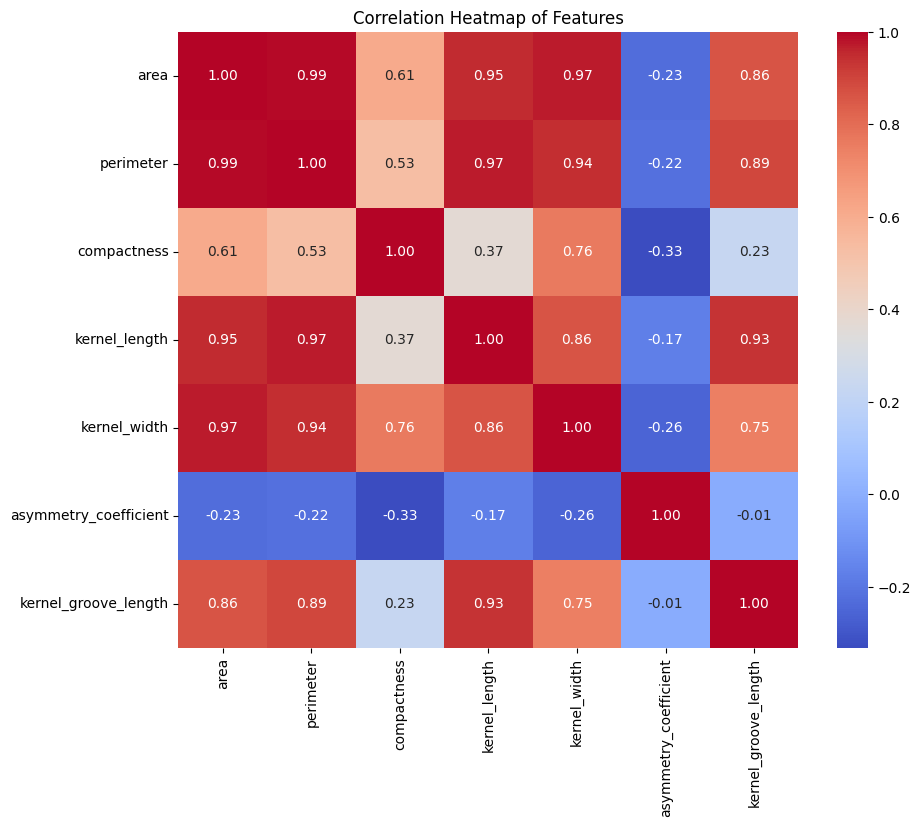

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Features')
plt.savefig('correlation_heatmap.png')

- **Redundancy:** There is a near-perfect correlation ($0.99$) between Area and Perimeter. 
- **Shape vs. Size:**  **Compactness** and **Asymmetry Coefficient** show low correlation with size-based features, meaning they provide unique geometric information that size alone cannot capture.

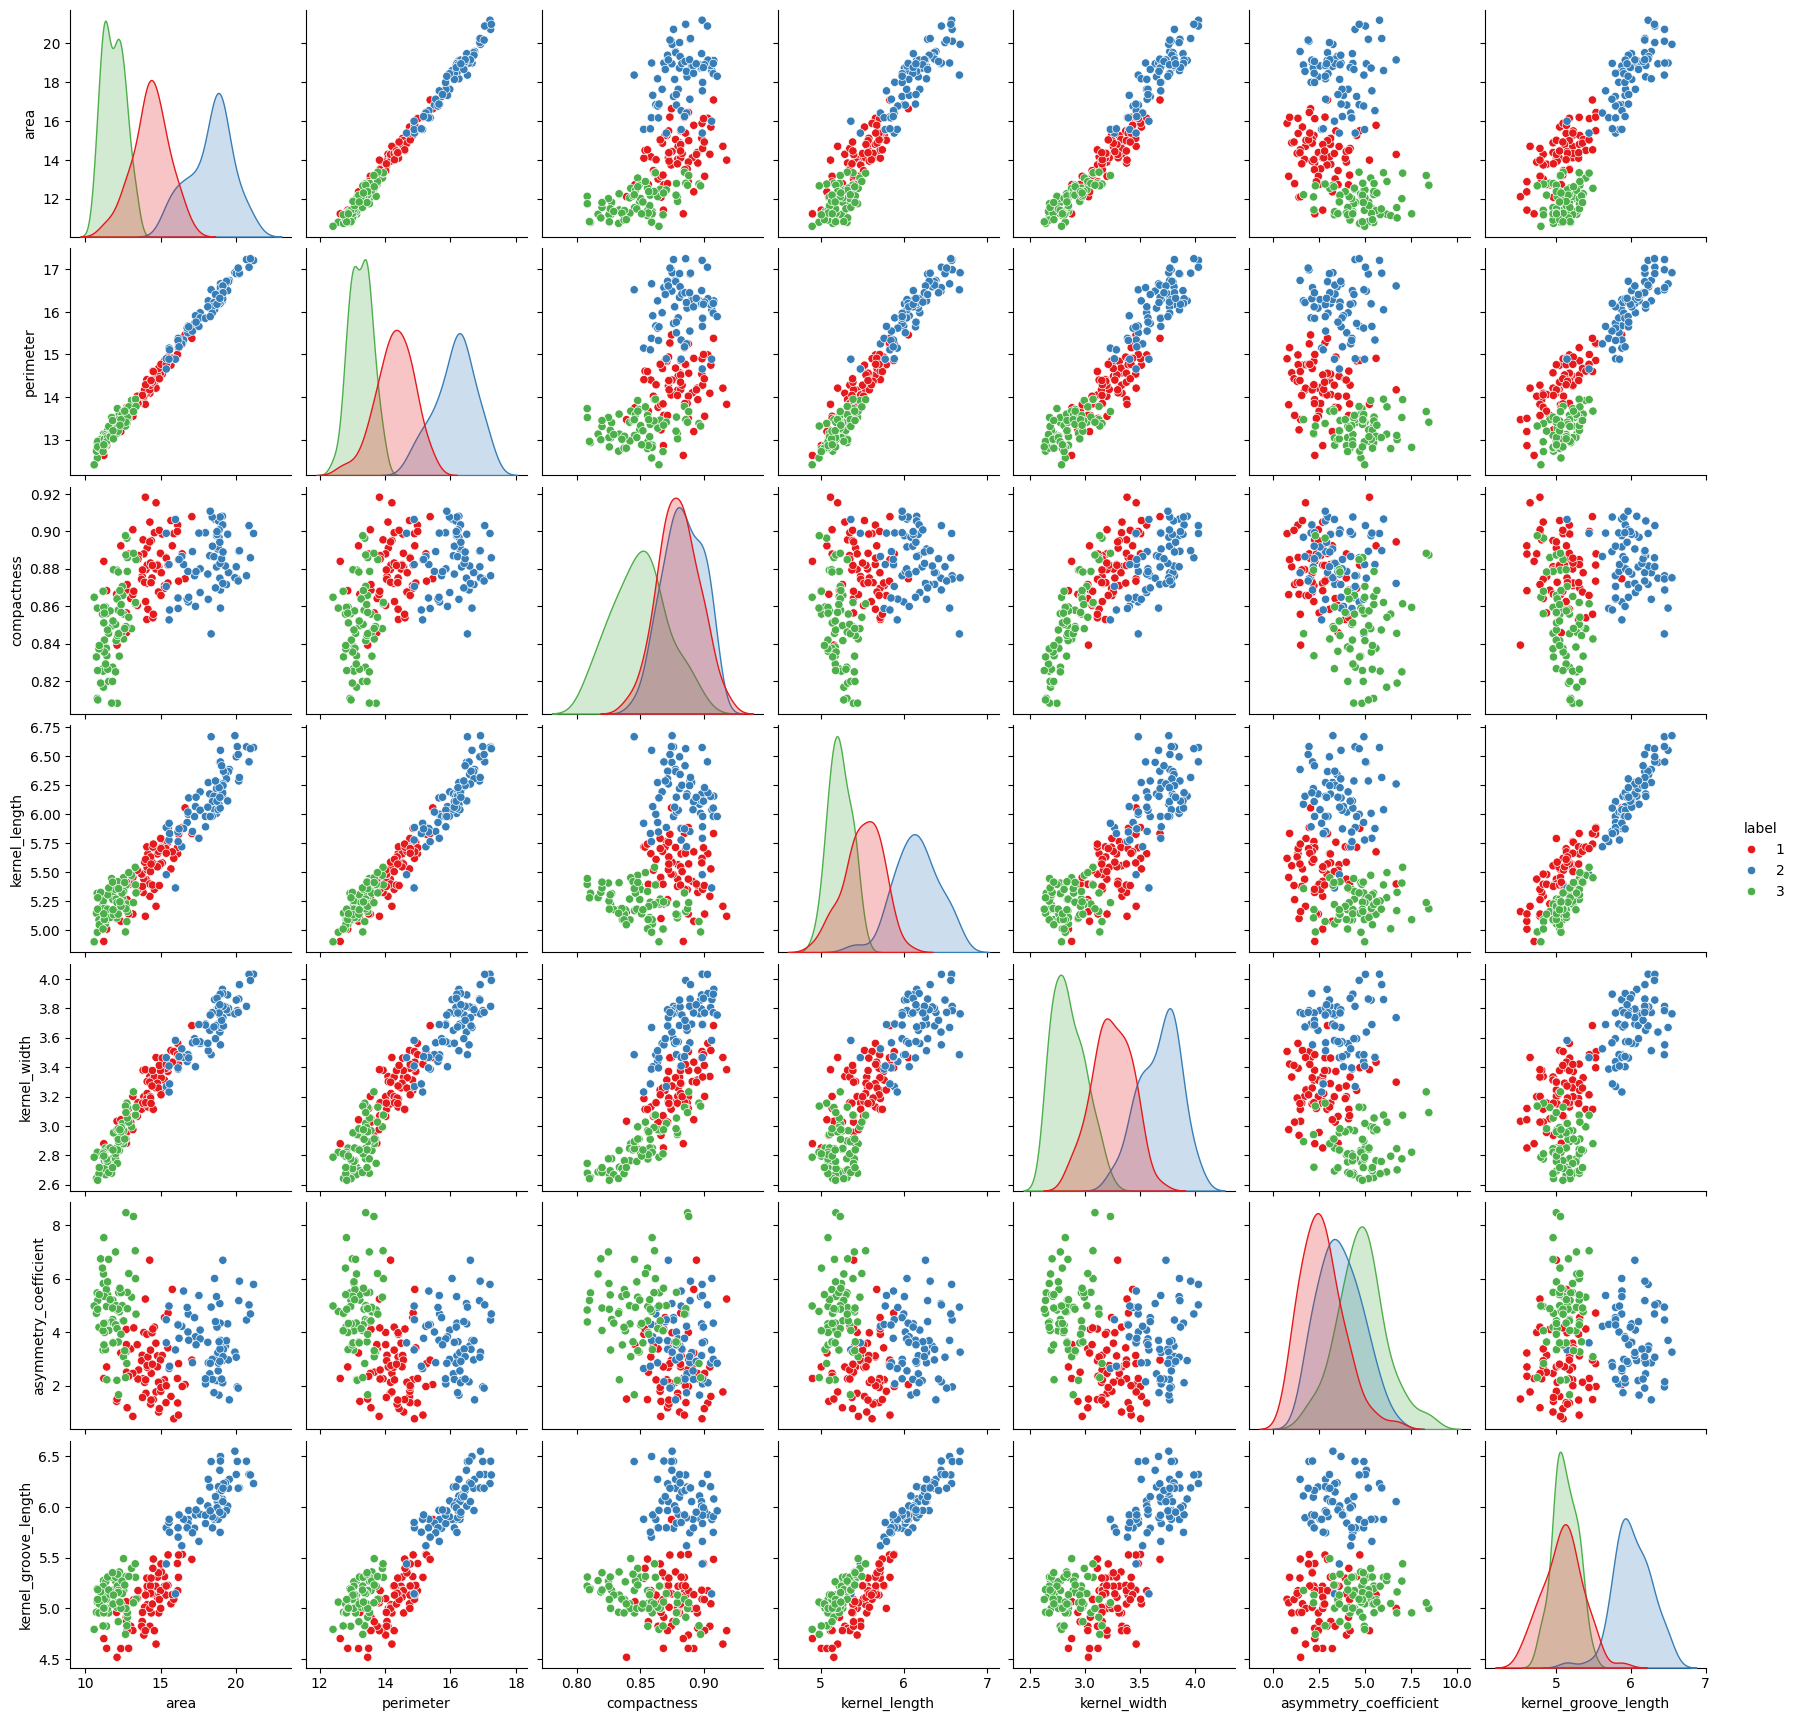

In [15]:
# Pairplot
pairplot_fig = sns.pairplot(df, hue='label', palette='Set1', diag_kind='kde')
pairplot_fig.savefig('pairplot.png')

##### The pairplot confirms that *Rosa* is linearly separable from the other two based on almost any size-related feature. *Kama* and *Canadian* are more tightly clustered together but show separation when comparing **Kernel Groove Length** against **Area**.

### **8. Principal Component Analysis (PCA)**

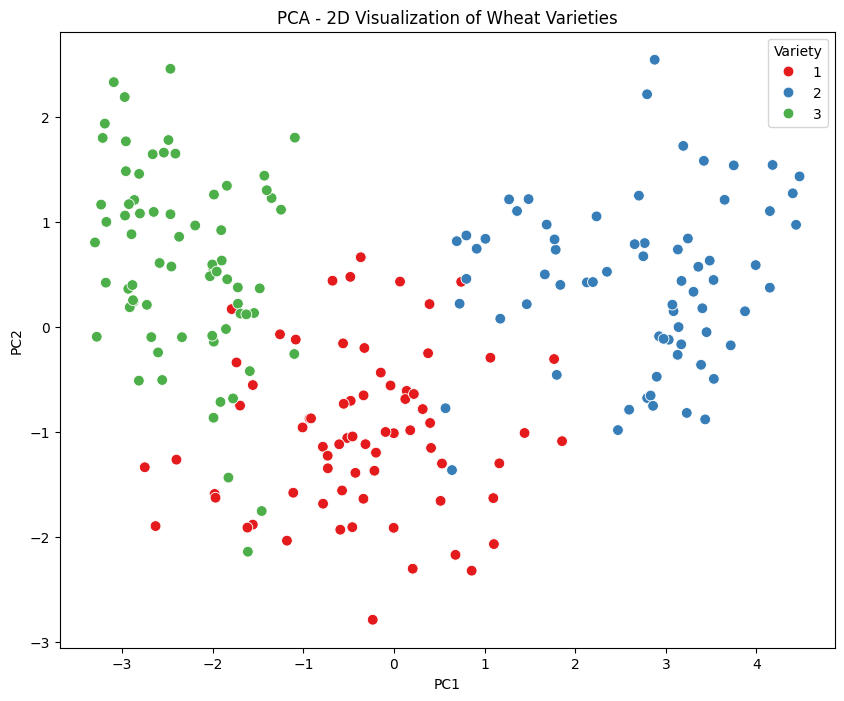

In [16]:
#  PCA
features = df.drop('label', axis=1)
labels = df['label']
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Variety'] = labels.values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Variety', palette='Set1', s=60)
plt.title('PCA - 2D Visualization of Wheat Varieties')
plt.savefig('pca_scatter.png')

# Save descriptive stats to CSV for user
desc_overall.to_csv('descriptive_stats_overall.csv')
# Flatten multi-index for per-class stats to save to CSV
desc_per_class_flat = desc_per_class.T.reset_index()
desc_per_class_flat.to_csv('descriptive_stats_per_class.csv')
if not outlier_df.empty:
    outlier_df.to_csv('outliers_documented.csv')

##### PCA was used to simplify the 7-dimensional dataset into 2 principal components ($PC1$ and $PC2$) that capture the most variance.  

##### Interpretation of Results:
  - **PC1 (Size and Perimeter):** The first component likely represents the overall size of the seed, as it clearly separates the large *Rosa* seeds from the smaller *Canadian* seeds.  
  - **PC2 (Shape and Asymmetry):** The second component captures shape variations that help differentiate *Kama* from *Canadian* seeds.  
  - **Visual Separability:** The 2D scatter plot shows three distinct clusters. This confirms that the geometric properties of wheat kernels are highly diagnostic, meaning a computer model can likely classify these varieties with very high accuracy (likely $>90\%$). 